## Imports

In [1]:
import geomstats.backend as gs
import karateclub as kc
import matplotlib.pyplot as plt
import networkx as nx
from networkx.drawing.nx_pydot import graphviz_layout
import numpy as np
import os
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import pydot
import random
import warnings

from geomstats.geometry.stratified.graph_space import GraphSpace
from geomstats.learning.aac import AAC
from plotly.subplots import make_subplots
from reeb_utils import do_reeb_for_start_end, do_reeb_for_explore_node, extract_tree_features, plot_treeb
from scipy.stats import pearsonr
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold


warnings.filterwarnings("ignore")
pd.options.mode.chained_assignment = None

INFO: NumExpr defaulting to 14 threads.


## Load data

In [2]:
# load data into dataframe
df = pd.read_csv("data/MLINDIV_train_full.csv")

test_df = df[df["eprocs"].str.contains("Test")]

test_df["subj_mean_acc"] = test_df.groupby("Subject")["accuracy"].transform("mean")
test_df["path_mean_acc"] = test_df.groupby(["StartAt", "EndAt"])["accuracy"].transform("mean")

test_df['quartile'] = (
    pd.qcut(test_df['subj_mean_acc'], 4, labels=[1, 2, 3, 4])
)

test_df["path_mean_acc_by_Q"] = test_df.groupby(["StartAt", "EndAt", "quartile"])["accuracy"].transform("mean")

## Generate all test-path Flow Trees

In [3]:
## BY PATH
flow_trees = []
paths = []
accs = []
for (start_node, end_node), group in test_df.groupby(["StartAt", "EndAt"]):
    G = do_reeb_for_start_end(test_df, start_node, end_node, 0, use_turns=False) # 0 means all quartiles
    new_G = nx.relabel.convert_node_labels_to_integers(G, first_label=0, ordering='default') # need to do for embeddings
    flow_trees.append(new_G)
    accs.append(group["path_mean_acc"].iloc[0])
    paths.append((start_node, end_node))

accs = np.array(accs)

In [81]:
from flow_tree_utils import generate_trajs_from_df, generate_flow_tree_from_trajs

# Function to generate bootstrapped trees
def generate_bootstrap_trees(group, k_fold=20, sample_frac=0.7, sample_size=20, reverse_trajs=False):
    trees = []
    for _ in range(k_fold):
        sampled_group = group.sample(frac=sample_frac)
        # Randomly select sample_size samples if group is larger than that
        if len(sampled_group) > sample_size:
            sampled_group = sampled_group.sample(n=sample_size)
        else:
            print("AAA")
        trajs = generate_trajs_from_df(sampled_group)
        if reverse_trajs:
            trajs = [list(reversed(t)) for t in trajs]
        G = generate_flow_tree_from_trajs(trajs, END_NODE="1")
        new_G = nx.relabel.convert_node_labels_to_integers(G, first_label=0, ordering='default')
        trees.append(new_G)
    return trees

## BY PATH
flow_trees = []
paths = []
accs = []
for (start_node, end_node), group in test_df.groupby(["StartAt", "EndAt"]):
    group = group[group["accuracy"]]
    trees = generate_bootstrap_trees(group, k_fold=3, sample_frac=0.7, sample_size=20)
    flow_trees.extend(trees)
    accs.extend([group["path_mean_acc"].iloc[0]]*3)
    paths.append([(start_node, end_node)]*3)

accs = np.array(accs)

AAA
AAA
AAA
AAA
AAA
AAA
AAA
AAA
AAA
AAA
AAA
AAA
AAA
AAA
AAA
AAA
AAA
AAA


## Compute all feature sets

### Baselines

#### Static features

In [71]:
## Baseline features
static_features = []

for (start_node, end_node), group in test_df.groupby(["StartAt", "EndAt"]):
    euclid_distance = group["Euc.Distance"].mode().iloc[0]
    path_distance = group["Path.Distance"].mode().iloc[0]
    num_nodes = group["Num.Nodes"].mode().iloc[0]
    
    avg_path_dist_traveled = group["path_dist_trav"].mean()
    avg_nodes_count = group["nodes_count"].mean()
    avg_turns_count = group["turns_count"].mean()
    # print(group[["Path.Distance", "Num.Nodes"]].mode())

    static_features.extend([[euclid_distance, path_distance, num_nodes, avg_path_dist_traveled, avg_nodes_count, avg_turns_count]]*3)

static_features = np.array(static_features)

#### Heatmaps

In [29]:
def letter_counts(strings):
    # Create a numpy array of zeros for 26 letters (A-Z)
    counts = np.zeros(26, dtype=int)
    
    # Loop through each string in the list
    for string in strings:
        for char in string:
            if 'A' <= char <= 'Z':  # Only consider capital letters
                index = ord(char) - ord('A')  # Convert letter to its corresponding index (A=0, B=1, ..., Z=25)
                counts[index] += 1

    return counts
    
## Heatmap features
heatmap_features = []
for (start_node, end_node), group in test_df.groupby(["StartAt", "EndAt"]):
    str_counts = np.zeros(26)
    for string in group["paths"]:
        for char in string:
            if 'A' <= char <= 'Z':
                index = ord(char) - ord('A')  # Convert letter to its corresponding index (A=0, B=1, ..., Z=25)
                str_counts[index] += 1
    str_counts /= np.sum(str_counts) 
    str_counts *= 10
    heatmap_features.extend([str_counts]*3)

# doing y and z makes everything horrible and crazy...
heatmap_features = np.array(heatmap_features)[:, :25]

### Flow Trees

#### Flow-Tree Features

In [82]:
def get_heaviest_path(tree, root):    
    # Get all leaves (nodes with degree 1, excluding the root)
    leaves = [node for node in tree.nodes() if tree.degree(node) == 1 and node != root]
    # leaves = [node for node in tree.nodes() if tree.nodes[node].get("color", "white") in ["yellow", "green"]]

    def dfs(node, current_path, current_weight):
        nonlocal max_weight, heaviest_path
        
        # If we're at a leaf (degree 1 and not root)
        if node in leaves:
            if current_weight > max_weight:
                max_weight = current_weight
                heaviest_path = current_path.copy()
            return
            
        # Explore all children
        for neighbor in tree.neighbors(node):
            if neighbor not in current_path:  # Avoid cycles
                edge_weight = tree[node][neighbor]['weight']
                current_path.append(neighbor)
                dfs(neighbor, current_path, current_weight + edge_weight)
                current_path.pop()
    
    max_weight = float('-inf')
    heaviest_path = None
    dfs(root, [root], 0)
    
    return heaviest_path, max_weight, [tree[heaviest_path[i]][heaviest_path[i+1]]['weight'] for i in range(len(heaviest_path)-1)]

def extract_tree_features(graph, root):
    # Number of Nodes
    num_nodes = graph.number_of_nodes()
    
    # Tree Depth (Height)
    def tree_depth(graph, root):
        depths = nx.single_source_shortest_path_length(graph, root)
        return max(depths.values())
    
    depth = tree_depth(graph, root)
    
    # Diameter
    diameter = nx.diameter(graph)

    backbone_path, max_weight, weights = get_heaviest_path(graph, root)
    backbone_thickness = np.mean(weights)
    
    # Number of Leaves
    num_leaves = sum(1 for node in graph.nodes() if graph.degree(node) == 1)
    
    # Branching Factor
    branching_factors = [len(list(graph.neighbors(node))) for node in graph.nodes()]
    avg_branching_factor = np.mean(branching_factors)
    
    # Put all features in a list
    features = [
        num_nodes,
        depth,
        diameter,
        num_leaves,
        avg_branching_factor,
        backbone_thickness
    ]
    
    return features

flow_tree_features = np.array([extract_tree_features(flow_tree, 0) for flow_tree in flow_trees])

#### Flow-Tree Embeddings

In [73]:
# https://karateclub.readthedocs.io/en/latest/modules/root.html#whole-graph-embedding
model = kc.Graph2Vec(dimensions=16)
model.fit(flow_trees)

flow_tree_embeddings = model.get_embedding()

INFO: collecting all words and their counts
INFO: PROGRESS: at example #0, processed 0 words (0 words/s), 0 word types, 0 tags
INFO: collected 113 word types and 216 unique tags from a corpus of 216 examples and 5601 words
INFO: Creating a fresh vocabulary
INFO: Doc2Vec lifecycle event {'msg': 'effective_min_count=5 retains 61 unique words (53.98% of original 113, drops 52)', 'datetime': '2025-03-20T15:49:35.432267', 'gensim': '4.3.3', 'python': '3.11.9 | packaged by conda-forge | (main, Apr 19 2024, 18:34:54) [Clang 16.0.6 ]', 'platform': 'macOS-14.1-arm64-arm-64bit', 'event': 'prepare_vocab'}
INFO: Doc2Vec lifecycle event {'msg': 'effective_min_count=5 leaves 5508 word corpus (98.34% of original 5601, drops 93)', 'datetime': '2025-03-20T15:49:35.432720', 'gensim': '4.3.3', 'python': '3.11.9 | packaged by conda-forge | (main, Apr 19 2024, 18:34:54) [Clang 16.0.6 ]', 'platform': 'macOS-14.1-arm64-arm-64bit', 'event': 'prepare_vocab'}
INFO: deleting the raw counts dictionary of 113 item

##### Visualise embeddings in 2D

In [74]:
# Reduce dimensionality to 2D for visualization
pca = PCA(n_components=2)
reduced_features = pca.fit_transform(flow_tree_embeddings)
# reduced_features = pca.fit_transform(features)

# to know if we can trust our eyes
# if it is very low then the higher dimension info matters a lot & we can't see
# above 0.7 is good!
print(pca.explained_variance_ratio_)

# Plot the clusters with Plotly to have interactive
fig = go.Figure()

# Scatter plot for 'Trees by Quartile'
fig.add_trace(go.Scatter(
    x=reduced_features[:, 0],
    y=reduced_features[:, 1],
    mode='markers',
    marker=dict(color=accs, colorscale='Viridis', showscale=True, 
                colorbar=dict(title="Path Accuracies", thickness=20, x=30, len=0.8)),
    name='Trees by Quartile',
))

# Update layout
fig.update_layout(
    title="PCA of Features",
    xaxis_title="PCA Component 1",
    yaxis_title="PCA Component 2",
    legend_title_text="Path Accuracies",
    height=500,
    width=500
)

fig.show()

# print(abs( pca.components_ ))

[0.09472971 0.08703801]


#### Flow-Tree Shapes

In [34]:
max_num_nodes = max(flow_trees, key=lambda x: x.number_of_nodes()).number_of_nodes()

# convert Flow Trees to padded adjacency matrices
padded_adj_mats = []
for ft in flow_trees:
    adj_mat = nx.adjacency_matrix(ft).todense()

    amt_to_pad = max_num_nodes - ft.number_of_nodes()
    padded_adj_mat = np.pad(adj_mat, pad_width=(0, amt_to_pad))

    padded_adj_mats.append(padded_adj_mat)

padded_adj_mats = np.array(padded_adj_mats)

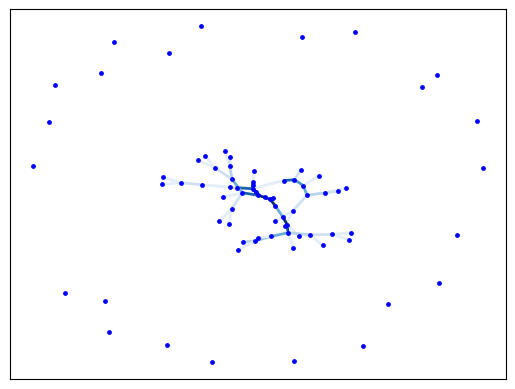

In [10]:
## STOLEN FROM GEOMSTATS DEMO
##  https://github.com/geomstats/geomstats/blob/main/notebooks/20_real_world_applications__graph_space.ipynb

gs.random.seed(2020)

mammals_obs = nx.from_numpy_array(padded_adj_mats[5])
pos = nx.kamada_kawai_layout(mammals_obs)
edges, weights = zip(*nx.get_edge_attributes(mammals_obs, "weight").items())

pos = nx.spring_layout(mammals_obs)
nx.draw_networkx_nodes(mammals_obs, pos, node_color="b", node_size=6)
nx.draw_networkx_edges(
    mammals_obs,
    pos,
    edgelist=edges,
    edge_color=weights,
    width=2.0,
    edge_cmap=plt.cm.Blues,
    edge_vmin=0.0,
    edge_vmax=10.0,
)

## normal to have all the floating nodes; this is what happens when you are padded

In [11]:
total_space = GraphSpace(n_nodes=padded_adj_mats.shape[1])
total_space.equip_with_group_action()
total_space.equip_with_quotient()

aac_fm = AAC(total_space, estimate="frechet_mean", max_iter=100)
aac_fm.fit(padded_adj_mats)

_AACFrechetMean(max_iter=100,
                space=<geomstats.geometry.stratified.graph_space.GraphSpace object at 0x2a5dd0a10>,
                total_space_estimator_kwargs={})

##### Plot Mean Flow Tree & verify distances

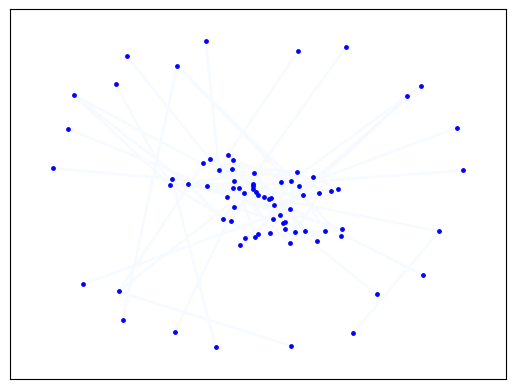

In [12]:
total_flow_trees_fm_mst = nx.minimum_spanning_tree(nx.from_numpy_array(aac_fm.estimate_))
edges, weights = zip(*nx.get_edge_attributes(total_flow_trees_fm_mst, "weight").items())

nx.draw_networkx_nodes(total_flow_trees_fm_mst, pos, node_color="b", node_size=6)
nx.draw_networkx_edges(
    total_flow_trees_fm_mst,
    pos,
    edgelist=edges,
    edge_color=weights,
    width=2.0,
    edge_cmap=plt.cm.Blues,
    edge_vmin=0.0,
    edge_vmax=10.0,
)

In [13]:
graph_space = total_space.quotient
graph_space

point_a, point_b, point_c = padded_adj_mats[0], padded_adj_mats[1], padded_adj_mats[-1]

dist_total = total_space.metric.dist(point_a, point_b)
dist_quotient = graph_space.metric.dist(point_a, point_b)

print(f"dist quotient <= dist total:\n{dist_quotient} <= {dist_total}")

print("dist a to c", graph_space.metric.dist(point_a, point_c))

dist quotient <= dist total:
71.07742257566744 <= 84.94704232638121
dist a to c 72.42927584892728


## Regressions

### Util fns

In [63]:
def run_evaluate_regression(X, y, feature_str="", axes=["", "", ""]):
    # Initialize and fit the linear regression model
    model = LinearRegression()
    
    ## K-fold cross validation
    
    # Define the number of folds
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    
    # Store RMSE for each fold
    rmse_list = []

    slopes = []
    
    # Perform the cross-validation
    for train_index, test_index in kf.split(X):
        # Split data
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]
        
        # Train the model
        model.fit(X_train, y_train)
        
        # Predict on the test set
        y_pred = model.predict(X_test)
        
        # Calculate RMSE
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        
        # Append RMSE to the list
        rmse_list.append(rmse)

        slopes.append(model.coef_)
    
    # Convert RMSE list to a numpy array for statistical calculations
    rmse_array = np.array(rmse_list)
    
    mean_rmse = np.mean(rmse_array)
    std_rmse = np.std(rmse_array)
    
    print(f"Mean RMSE: {mean_rmse}")
    print(f"Standard Deviation of RMSE: {std_rmse}")
    
    # Get the regression coefficient and intercept
    slopes = np.array(slopes)
    slope = np.mean(np.abs(slopes), axis=0)
    intercept = model.intercept_
    
    print(f"Linear Regression Coefficients:", slope)
    print(feature_str)
    print(f"Intercept: {intercept:.2f}")
    print(f"R-squared: {model.score(X, y):.2f}")

    print(X.shape)
    print(y.shape)

    # Correlations
    # Initialize lists to store correlations and p-values
    correlations = []
    p_values = []
    
    # Loop through each feature (column) in X
    for i in range(X.shape[1]):
        corr, p_value = pearsonr(X[:, i], y)
        correlations.append(corr)
        p_values.append(p_value)
    
    # Convert to numpy array for easier manipulation
    correlations = np.array(correlations)
    p_values = np.array(p_values)

    # Identify top 3 most important features based on absolute value of coefficients
    top_features_indices = np.argsort(np.abs(slope))[-3:]  # Indices of the top 3 features
    top_features_names = np.array(feature_str.split(","))[top_features_indices]   # Names of the top 3 features
    
    # Create subplots with 3 plots (one for each top feature)
    fig = make_subplots(rows=1, cols=3, subplot_titles=top_features_names)
    
    # Plot each feature against the true y values in separate subplots
    j = 0
    for i in reversed(top_features_indices):
        feature_name = np.array(feature_str.split(","))[i]

        print(X[i].shape)
        # Scatter plot: feature vs actual y
        fig.add_trace(go.Scatter(x=X[:,i], y=y, mode='markers', name=f'corr={correlations[i]:0.3f}, p={p_values[i]:0.3f}'),
                      row=1, col=j+1)

        feature_model = LinearRegression()
        feature_X = X[:,i:i+1] 
        feature_model.fit(feature_X, y)
        
        # Plot regression line: feature vs predicted y (y_pred)
        # Create values for the best-fit line
        feature_x_range = np.linspace(X[:,i].min(), X[:,i].max(), 100)
        feature_y_pred = feature_model.predict(feature_x_range.reshape(-1, 1))

        fig.add_trace(go.Scatter(x=feature_x_range, y=feature_y_pred, mode='lines', name=f'{slope[i]:0.2f} {feature_name} regression line'),
                      row=1, col=j+1)

        fig.update_xaxes(title_text=axes[j]+f"<br>(r={correlations[i]:0.3f}, p={p_values[i]:0.3f})", title_standoff=3, row=1, col=j+1)

        j+=1
    
    # Update layout to make the plot visually appealing
    fig.update_layout(
        title_text="Top 3 Features vs Target Variable",
        height=400,
        width=1200,
        paper_bgcolor='white',  # Set paper background to white
        plot_bgcolor='white'    # Set plot background to white
    )
    fig.update_yaxes(title_text="path success rate", title_standoff=3, row=1, col=1)
    # Show plot
    fig.show()

def run_evaluate_knn_regression(X, y, distance_fn, k=5):

    # Initialize and fit the linear regression model
    model = KNNRegressor(k=k, distance_func=distance_fn)
    
    ## K-fold cross validation
    
    # Define the number of folds
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    
    # Store RMSE for each fold
    rmse_list = []
    
    # Perform the cross-validation
    for train_index, test_index in kf.split(X):
        # Split data
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]
        
        # Train the model
        model.fit(X_train, y_train)
        
        # Predict on the test set
        y_pred = model.predict(X_test)
        
        # Calculate RMSE
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        
        # Append RMSE to the list
        rmse_list.append(rmse)
    
    # Convert RMSE list to a numpy array for statistical calculations
    rmse_array = np.array(rmse_list)
    
    mean_rmse = np.mean(rmse_array)
    std_rmse = np.std(rmse_array)
    
    print(f"Mean RMSE: {mean_rmse}")
    print(f"Standard Deviation of RMSE: {std_rmse}")


#### KNN

In [36]:
class KNNRegressor:
    def __init__(self, k, distance_func):
        self.k = k  # Number of nearest neighbors
        self.distance_func = distance_func  # Custom distance function

    def fit(self, X_train, y_train):
        """
        Store the training data.
        :param X_train: Training features, shape (n_samples, n_features)
        :param y_train: Training labels (target values), shape (n_samples,)
        """
        self.X_train = X_train
        self.y_train = y_train

    def predict(self, X_test):
        """
        Predict the target values for the test data.
        :param X_test: Test features, shape (n_samples, n_features)
        :return: Predicted target values, shape (n_samples,)
        """
        predictions = []
        for x_test in X_test:
            # Calculate the distances between the test point and all training points
            distances = [self.distance_func(x_test, x_train) for x_train in self.X_train]
            # Get the indices of the k nearest neighbors
            k_indices = np.argsort(distances)[:self.k]
            # Get the target values of the k nearest neighbors
            k_nearest_values = self.y_train[k_indices]
            # Predict by averaging the k nearest target values
            predictions.append(np.mean(k_nearest_values))
        return np.array(predictions)

def shape_dist(p1, p2):
    return graph_space.metric.dist(p1, p2)
    
def euclid_dist(p1, p2):
    return np.linalg.norm(p1-p2)

### Run KNN Regressions

In [60]:
print("Baseline:")
run_evaluate_knn_regression(static_features[:,0].reshape(-1, 1), accs, euclid_dist, k=5)

print("Heatmap:") 
run_evaluate_knn_regression(heatmap_features, accs, euclid_dist, k=5)

print("Flow-Tree Features:")
run_evaluate_knn_regression(flow_tree_features, accs, euclid_dist, k=5)

print("Flow-Tree Embeddings:")
run_evaluate_knn_regression(reduced_features, accs, euclid_dist, k=5)

# print("Flow-Tree Shapes:")
# run_evaluate_knn_regression(padded_adj_mats, accs, shape_dist, k=5)

Baseline:
Mean RMSE: 0.0828800015949749
Standard Deviation of RMSE: 0.0023245056537894494
Heatmap:
Mean RMSE: 0.06901684218084132
Standard Deviation of RMSE: 0.006315163905832115
Flow-Tree Features:
Mean RMSE: 0.07062375032420161
Standard Deviation of RMSE: 0.007661642398979233
Flow-Tree Embeddings:
Mean RMSE: 0.09975735619246959
Standard Deviation of RMSE: 0.010981094183053533


### Run Linear Regressions

#### Baseline Static Features

In [77]:
baseline_feature_str = """static_baseline_features = [
        euclid_distance, 
        path_distance, 
        num_nodes, 
        avg_path_dist_traveled, 
        avg_nodes_count, 
        avg_turns_count
    ]"""
# run_evaluate_regression(static_features, accs, feature_str=baseline_feature_str, axes=["avg num turns taken", "avg traj Euc distance", "avg traj nodes traversed"])
# get_correlation_p_values(static_features, accs)
run_evaluate_regression(static_features[:,0].reshape(-1, 1), accs, feature_str=baseline_feature_str, axes=["avg num turns taken", "avg traj Euc distance", "avg traj nodes traversed"])
run_evaluate_regression(static_features[:,-2].reshape(-1, 1), accs, feature_str=baseline_feature_str, axes=["avg num turns taken", "avg traj Euc distance", "avg traj nodes traversed"])

Mean RMSE: 0.09337927620037642
Standard Deviation of RMSE: 0.010563865208600096
Linear Regression Coefficients: [0.00287988]
static_baseline_features = [
        euclid_distance, 
        path_distance, 
        num_nodes, 
        avg_path_dist_traveled, 
        avg_nodes_count, 
        avg_turns_count
    ]
Intercept: 0.60
R-squared: 0.01
(216, 1)
(216,)
(1,)


Mean RMSE: 0.08817187941195367
Standard Deviation of RMSE: 0.00963130802367583
Linear Regression Coefficients: [0.03003767]
static_baseline_features = [
        euclid_distance, 
        path_distance, 
        num_nodes, 
        avg_path_dist_traveled, 
        avg_nodes_count, 
        avg_turns_count
    ]
Intercept: 0.82
R-squared: 0.12
(216, 1)
(216,)
(1,)


#### Baseline Heatmaps

In [40]:
heatmap_feature_str = """string counts = [A,B,C,D,E,F,G,H,I,J,K,L,M,N,O,P,Q,R,S,T,U,V,W,X,Y,Z]"""
run_evaluate_regression(heatmap_features, accs, feature_str=heatmap_feature_str, axes=["pct Y visits", "pct X visits", "pct V visits"])

Mean RMSE: 0.06482892878574081
Standard Deviation of RMSE: 0.0044568903215957915
Linear Regression Coefficients: [0.0200243  0.07973439 0.03253418 0.14892891 0.03569624 0.1563903
 0.06445739 0.06250851 0.0543421  0.03140281 0.05237919 0.02526281
 0.2090197  0.21297037 0.1342591  0.04304889 0.13237447 0.18609362
 0.09571026 0.07894417 0.03686651 0.24966556 0.0302016  0.24535263
 0.1950131 ]
string counts = [A,B,C,D,E,F,G,H,I,J,K,L,M,N,O,P,Q,R,S,T,U,V,W,X,Y,Z]
Intercept: 1.15
R-squared: 0.61
(216, 25)
(216,)
(25,)
(25,)
(25,)


#### Flow-Tree Features

In [84]:
tree_feature_str = """tree_features = [
        num_nodes,
        depth,
        diameter,
        num_leaves,
        avg_branching_factor,
        backbone_thickness
    ]"""

# Normalize flow tree features to 0-1 range for each column
flow_tree_features = (flow_tree_features - flow_tree_features.min(axis=0)) / (flow_tree_features.max(axis=0) - flow_tree_features.min(axis=0))
print(flow_tree_features)
# run_evaluate_regression(flow_tree_features, accs, feature_str=tree_feature_str, axes=["avg branching factor", "number of edges", "number of nodes"])
run_evaluate_regression(flow_tree_features[:,0].reshape(-1, 1), accs, feature_str=tree_feature_str, axes=["avg branching factor", "number of edges", "number of nodes"])
run_evaluate_regression(flow_tree_features[:,1].reshape(-1, 1), accs, feature_str=tree_feature_str, axes=["avg branching factor", "number of edges", "number of nodes"])
run_evaluate_regression(flow_tree_features[:,-2].reshape(-1, 1), accs, feature_str=tree_feature_str, axes=["avg branching factor", "number of edges", "number of nodes"])
run_evaluate_regression(flow_tree_features[:,-1].reshape(-1, 1), accs, feature_str=tree_feature_str, axes=["avg branching factor", "number of edges", "number of nodes"])

[[0.1875     0.25       0.33333333 0.125      0.675      0.86666667]
 [0.1875     0.25       0.33333333 0.125      0.675      0.8       ]
 [0.1875     0.25       0.33333333 0.125      0.675      0.86666667]
 ...
 [0.1875     0.25       0.33333333 0.125      0.675      0.86666667]
 [0.3125     0.25       0.5        0.25       0.80357143 0.76666667]
 [0.1875     0.25       0.33333333 0.125      0.675      0.86666667]]
Mean RMSE: 0.09359497227614072
Standard Deviation of RMSE: 0.009129713507378403
Linear Regression Coefficients: [0.06074012]
tree_features = [
        num_nodes,
        depth,
        diameter,
        num_leaves,
        avg_branching_factor,
        backbone_thickness
    ]
Intercept: 0.61
R-squared: 0.01
(216, 1)
(216,)
(1,)


Mean RMSE: 0.0933562793299453
Standard Deviation of RMSE: 0.008414347239287882
Linear Regression Coefficients: [0.061211]
tree_features = [
        num_nodes,
        depth,
        diameter,
        num_leaves,
        avg_branching_factor,
        backbone_thickness
    ]
Intercept: 0.61
R-squared: 0.02
(216, 1)
(216,)
(1,)


Mean RMSE: 0.09310408332857423
Standard Deviation of RMSE: 0.00790534086474441
Linear Regression Coefficients: [0.07860617]
tree_features = [
        num_nodes,
        depth,
        diameter,
        num_leaves,
        avg_branching_factor,
        backbone_thickness
    ]
Intercept: 0.66
R-squared: 0.03
(216, 1)
(216,)
(1,)


Mean RMSE: 0.09328384424652973
Standard Deviation of RMSE: 0.010128487899134843
Linear Regression Coefficients: [0.06283993]
tree_features = [
        num_nodes,
        depth,
        diameter,
        num_leaves,
        avg_branching_factor,
        backbone_thickness
    ]
Intercept: 0.53
R-squared: 0.02
(216, 1)
(216,)
(1,)


In [ ]:
# Create a DataFrame to store hypothesis test results
def get_new_results_df():
    return pd.DataFrame(columns=[
        'hypothesis',
        'test_type',
        'group1_name',
        'group2_name',
        'group1_mean',
        'group2_mean',
        'group1_var',
        'group2_var',
        'group1_n',
        'group2_n',
        'statistic',
        'p_value',
        'significant',
        'metric',
        'notes'
    ])

all_results_df = get_new_results_df()

#### Flow-Tree Embeddings

In [43]:
pca = PCA(n_components=3)
reduced_features = pca.fit_transform(flow_tree_embeddings)

embedding_feature_str = """
        pca1_graph2vec (16d),
        pca2_graph2vec (16d),
        pca3_graph2vec (16d)
    ]"""

# embedding_feature_str = str(list(range(16)))
run_evaluate_regression(reduced_features, accs, feature_str=embedding_feature_str, axes=["embeddings pca-1", "embeddings pca-2", "embeddings pca-3"])

Mean RMSE: 0.0943502920546604
Standard Deviation of RMSE: 0.008561235162158587
Linear Regression Coefficients: [0.07489861 0.17290309 0.08643073]

        pca1_graph2vec (16d),
        pca2_graph2vec (16d),
        pca3_graph2vec (16d)
    ]
Intercept: 0.58
R-squared: 0.01
(216, 3)
(216,)
(3,)
(3,)
(3,)


### Plot all treebs
just for fun; not super sure what this was, but seems like I shouldn't delete it just yet

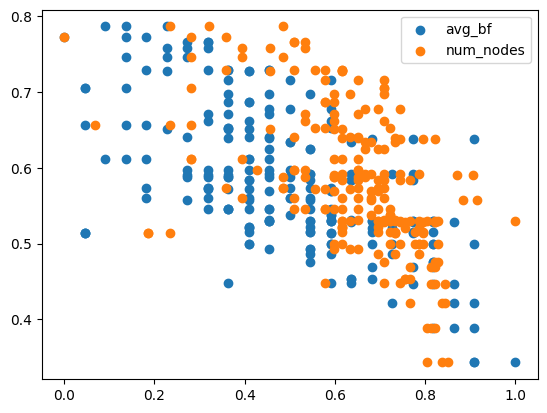

In [46]:
deg = flow_tree_features[:, 3]
bf = flow_tree_features[:, -2]

plt.scatter((deg - min(deg)) / (max(deg) - min(deg)), accs, label="avg_bf")
plt.scatter((bf - min(bf)) / (max(bf) - min(bf)), accs, label="num_nodes")

plt.legend()
plt.show()

# sorted_order = [x for x in sorted(range(len(accs)), key=lambda x: accs[x])]
# c=0
# for i, tree_index in enumerate(sorted_order):
#     print(f"acc: {accs[tree_index]:.2f}, avg_degree: {features[tree_index][4]}, avg_bf: {features[tree_index][-2]}")

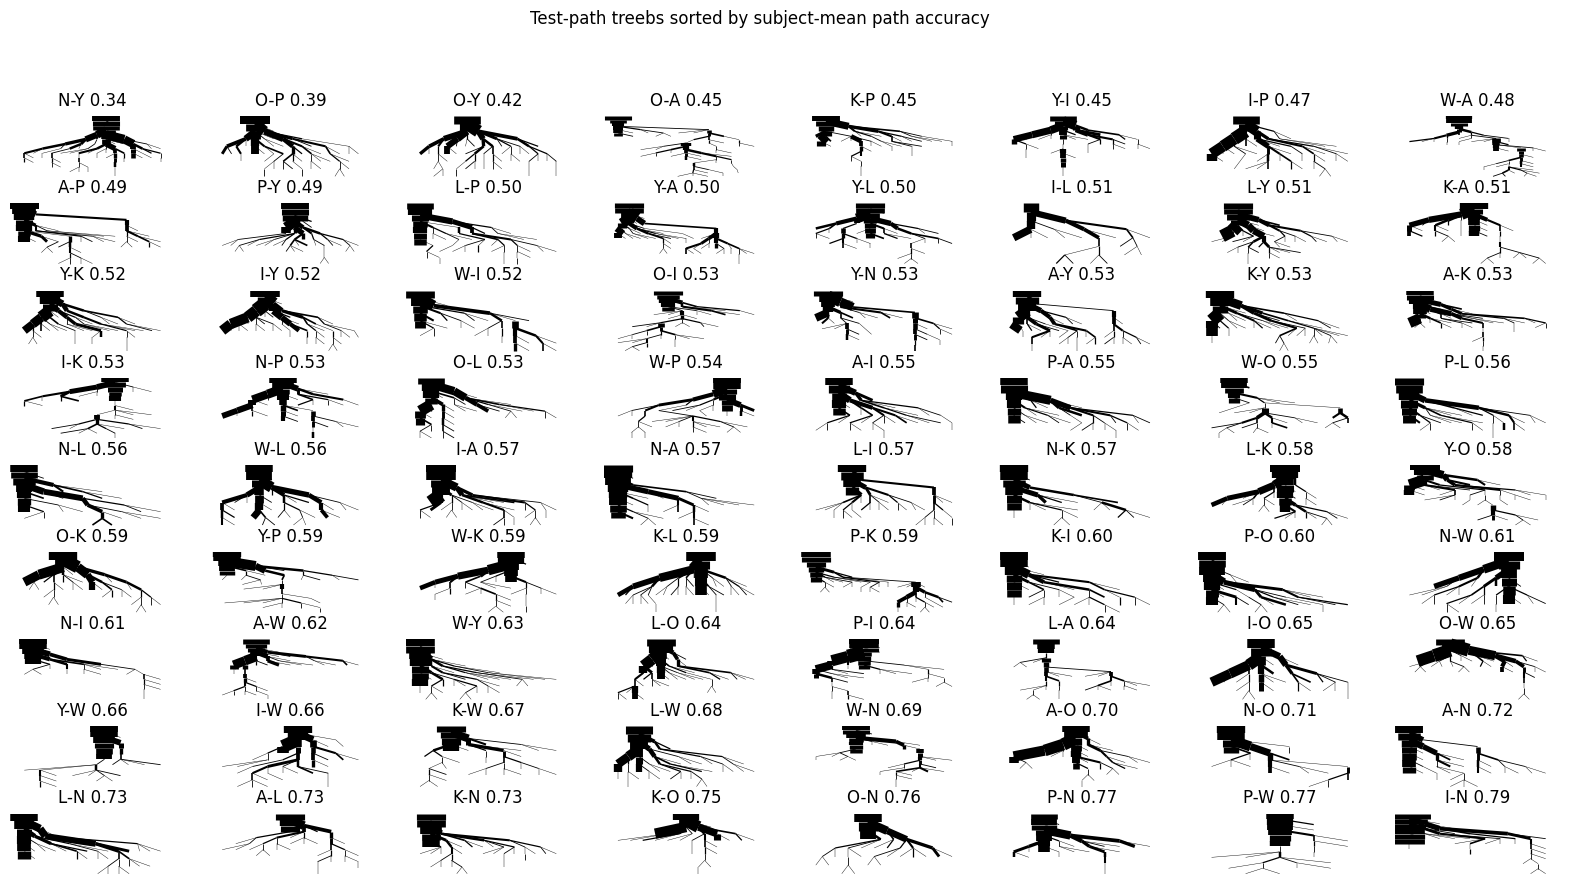

In [22]:
fig, axes = plt.subplots(9, 8, figsize=(20,10))

sorted_order = [x for x in sorted(range(len(accs)), key=lambda x: accs[x])]
c=0
for i, tree_index in enumerate(sorted_order):
    G = flow_trees[tree_index]
    
    ax = axes[i // 8][i % 8]
    pos = graphviz_layout(G, prog="dot")
    
    edges = G.edges()
    weights = [G[u][v]['weight'] * .3 for u,v in edges]

    nodes = G.nodes()
    n_labels = {n: n for n in G}
    n_colors = [G.nodes[n].get("color", "blue") for n in nodes]

    # nx.draw_networkx_nodes(G, pos, node_color=n_colors, node_size=500, alpha=0.7, ax=ax)
    nx.draw_networkx_edges(G, pos, edgelist=edges, width=weights, ax=ax)
    # nx.draw_networkx_labels(G, pos, labels=n_labels, font_size=13, ax=ax) # font_weight="bold",

    ax.axis("off")
    ax.set_title(f"{'-'.join(paths[tree_index])} {accs[tree_index]:.2f}", pad=-5)
    
    
    # if c>10:
    #     break
    # c += 1

fig.suptitle("Test-path treebs sorted by subject-mean path accuracy")
fig.savefig("figures/test_treebs_by_acc.png")

plt.show()


# compare to baseline
#   of min path distance!


# compute only treeb of get it right? 
# try treeb of people who get it wrong??

Treeb 39, acc=0.34, path=('N', 'Y')


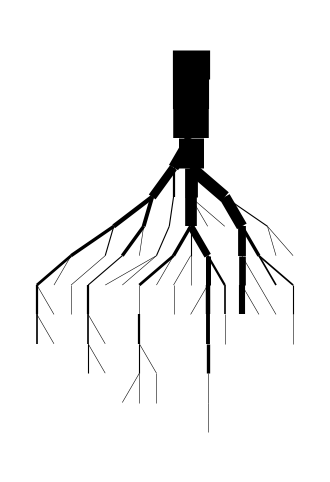

Treeb 45, acc=0.39, path=('O', 'P')


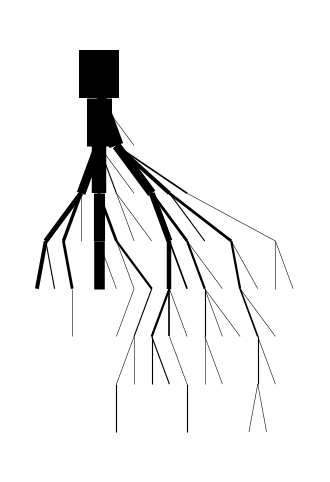

Treeb 47, acc=0.42, path=('O', 'Y')


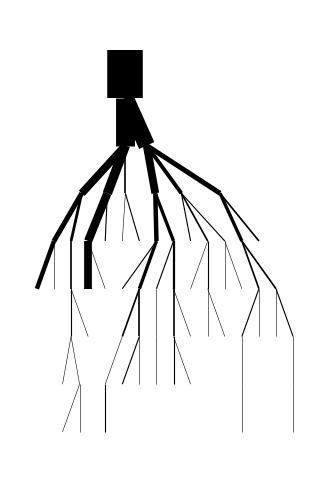

Treeb 40, acc=0.45, path=('O', 'A')


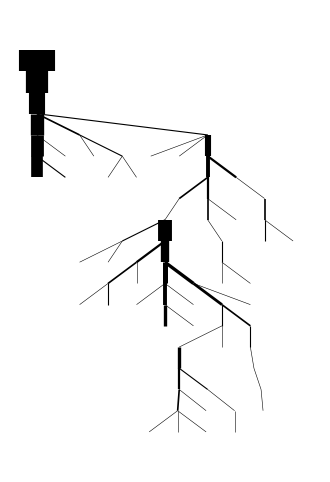

Treeb 21, acc=0.45, path=('K', 'P')


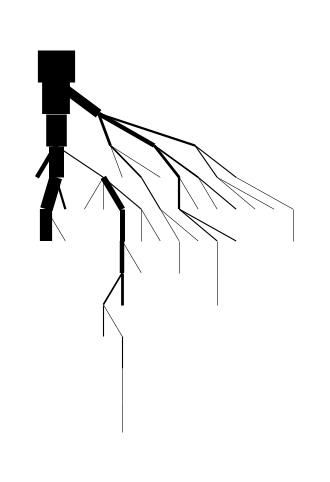

Treeb 65, acc=0.45, path=('Y', 'I')


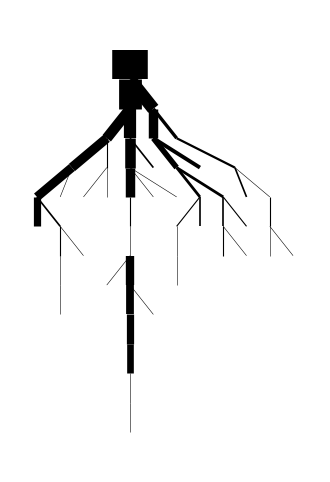

Treeb 13, acc=0.47, path=('I', 'P')


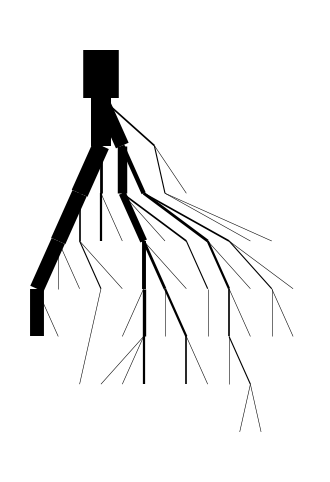

Treeb 56, acc=0.48, path=('W', 'A')


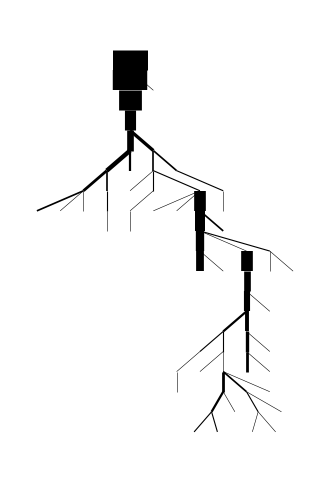

Treeb 5, acc=0.49, path=('A', 'P')


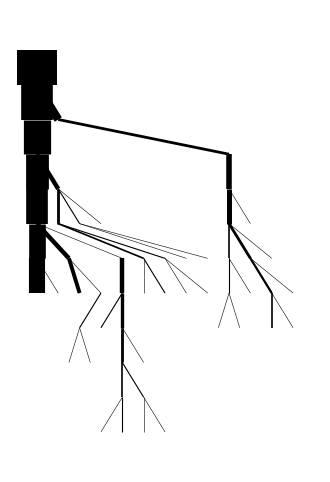

Treeb 55, acc=0.49, path=('P', 'Y')


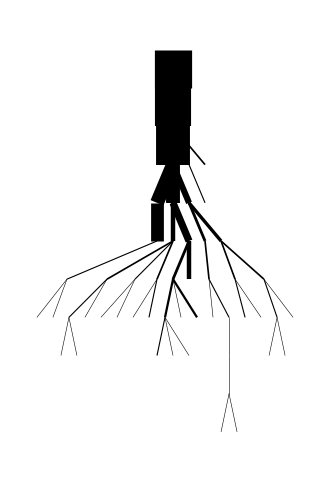

Treeb 29, acc=0.50, path=('L', 'P')


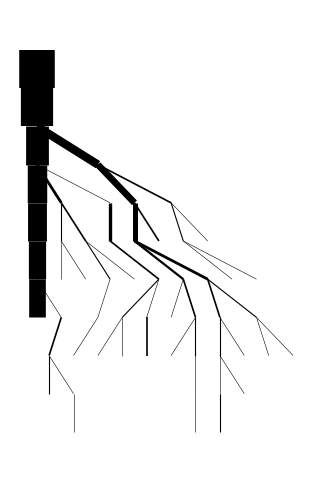

Treeb 64, acc=0.50, path=('Y', 'A')


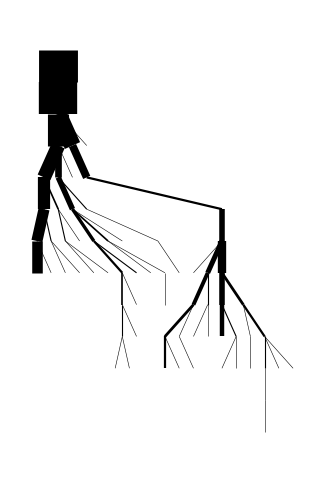

Treeb 67, acc=0.50, path=('Y', 'L')


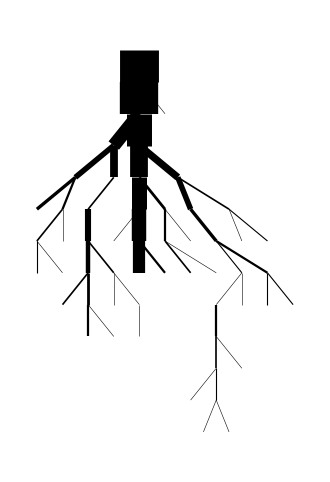

Treeb 10, acc=0.51, path=('I', 'L')


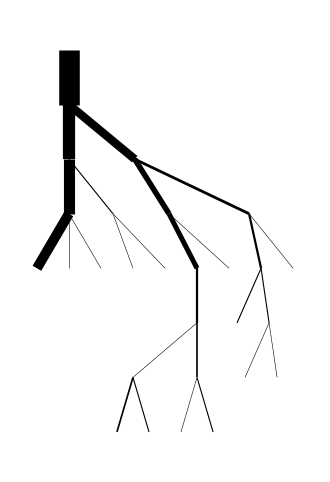

Treeb 31, acc=0.51, path=('L', 'Y')


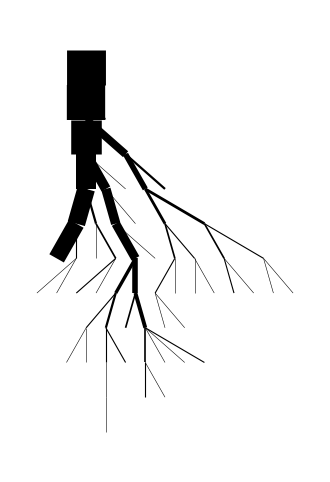

Treeb 16, acc=0.51, path=('K', 'A')


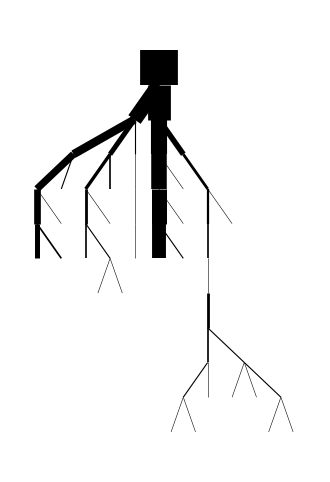

Treeb 66, acc=0.52, path=('Y', 'K')


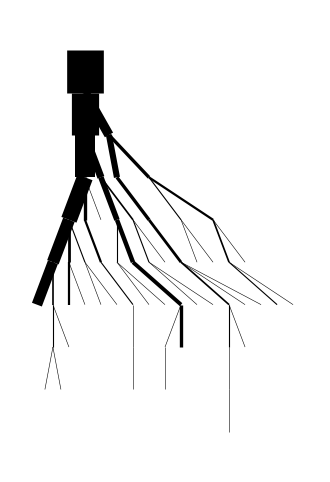

Treeb 15, acc=0.52, path=('I', 'Y')


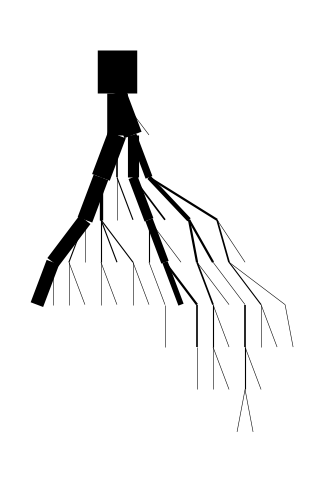

Treeb 57, acc=0.52, path=('W', 'I')


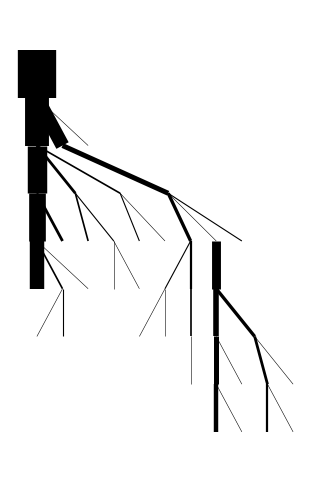

Treeb 41, acc=0.53, path=('O', 'I')


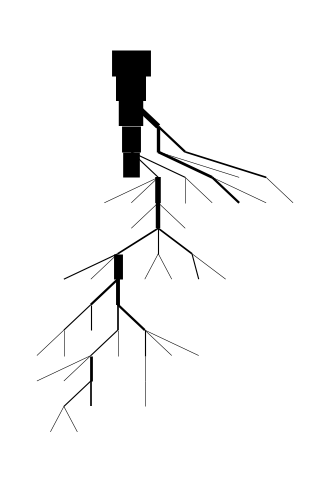

Treeb 68, acc=0.53, path=('Y', 'N')


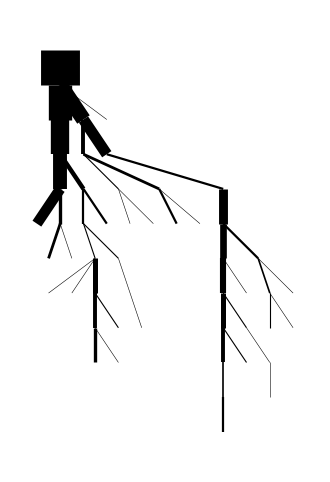

Treeb 7, acc=0.53, path=('A', 'Y')


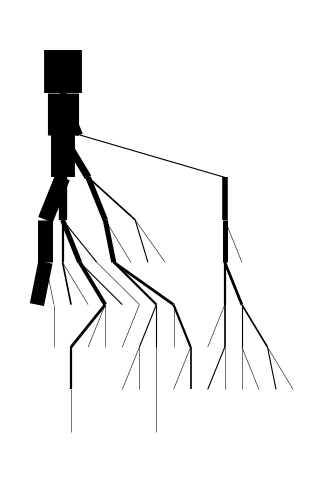

Treeb 23, acc=0.53, path=('K', 'Y')


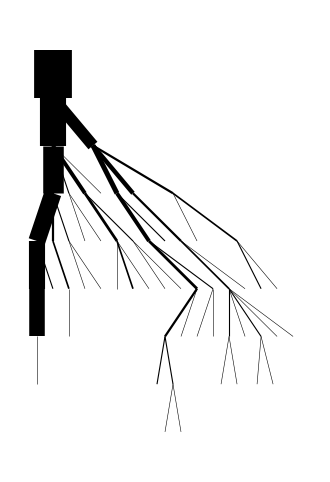

Treeb 1, acc=0.53, path=('A', 'K')


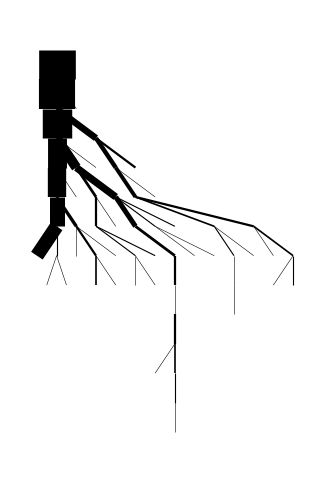

Treeb 9, acc=0.53, path=('I', 'K')


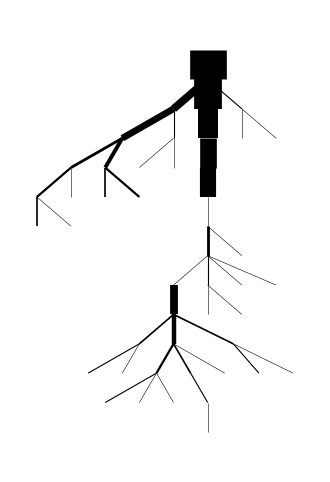

Treeb 37, acc=0.53, path=('N', 'P')


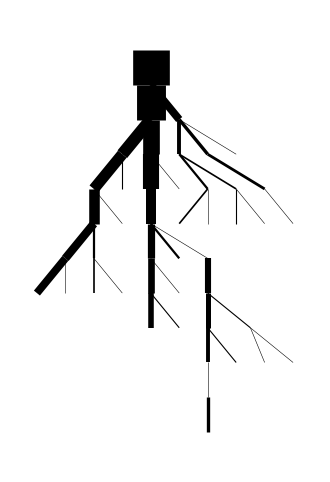

Treeb 43, acc=0.53, path=('O', 'L')


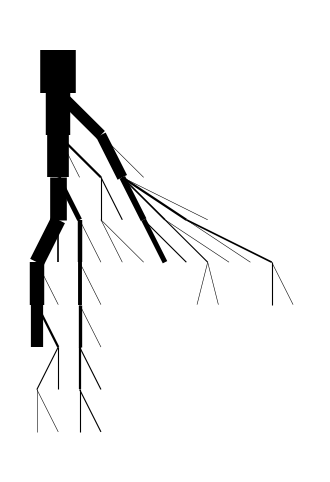

Treeb 62, acc=0.54, path=('W', 'P')


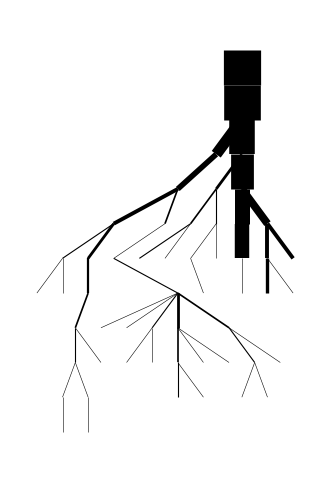

Treeb 0, acc=0.55, path=('A', 'I')


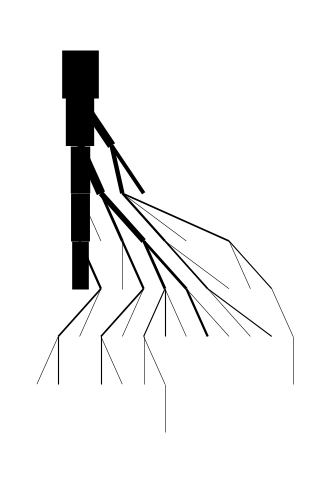

Treeb 48, acc=0.55, path=('P', 'A')


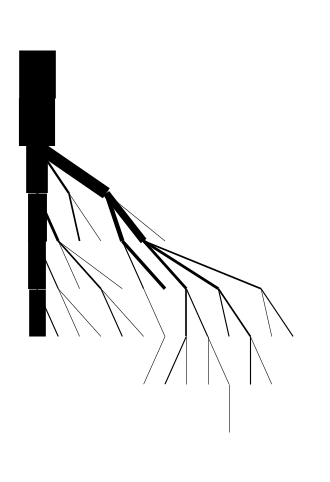

Treeb 61, acc=0.55, path=('W', 'O')


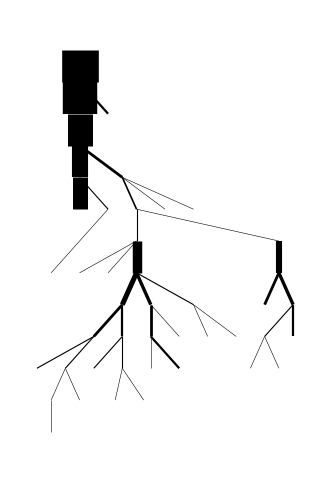

Treeb 51, acc=0.56, path=('P', 'L')


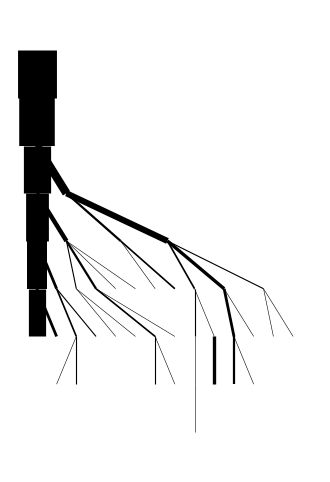

Treeb 35, acc=0.56, path=('N', 'L')


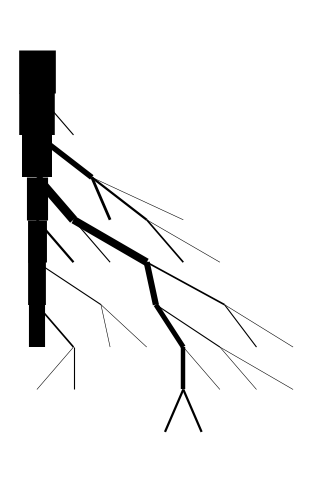

Treeb 59, acc=0.56, path=('W', 'L')


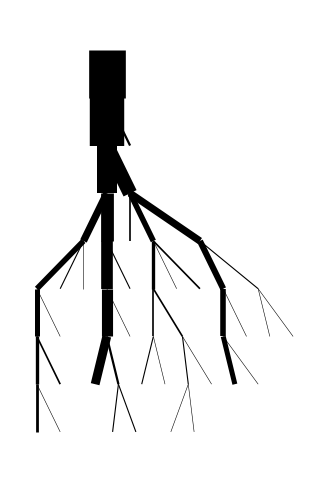

Treeb 8, acc=0.57, path=('I', 'A')


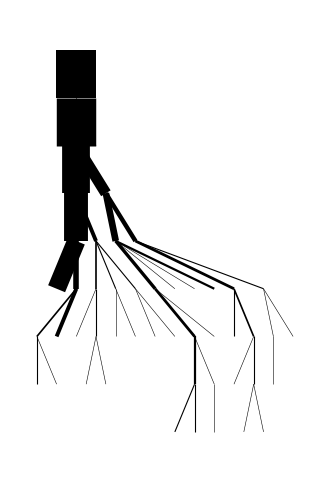

Treeb 32, acc=0.57, path=('N', 'A')


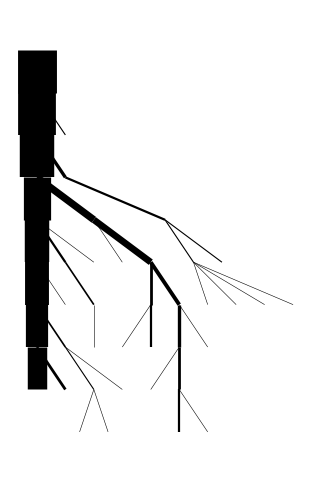

Treeb 25, acc=0.57, path=('L', 'I')


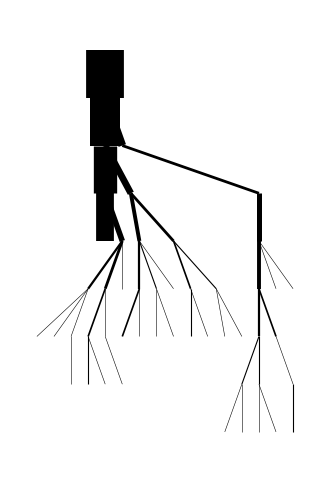

Treeb 34, acc=0.57, path=('N', 'K')


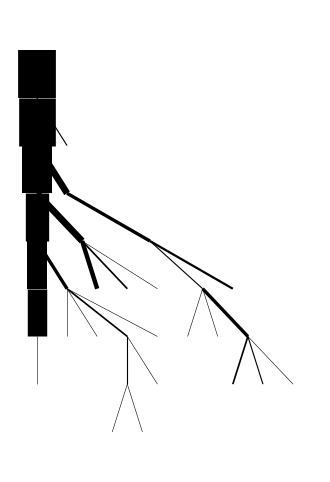

Treeb 26, acc=0.58, path=('L', 'K')


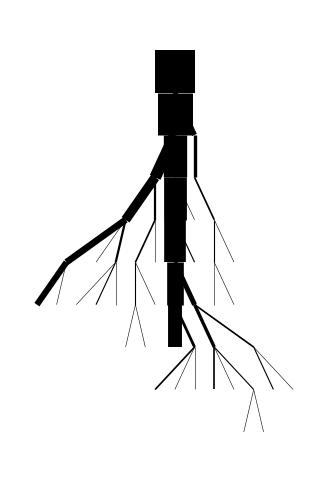

Treeb 69, acc=0.58, path=('Y', 'O')


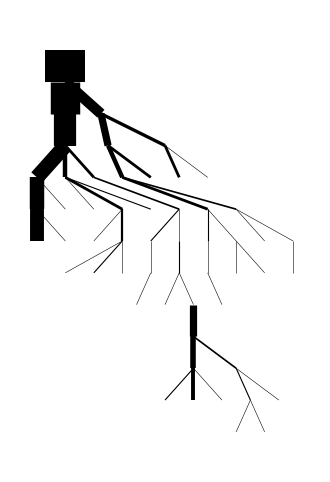

Treeb 42, acc=0.59, path=('O', 'K')


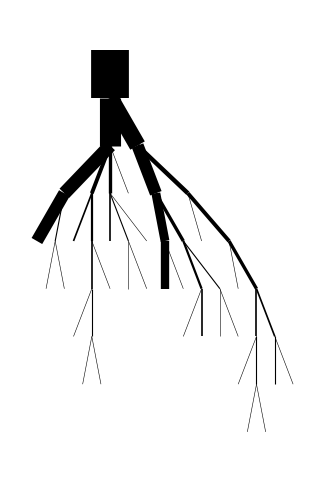

Treeb 70, acc=0.59, path=('Y', 'P')


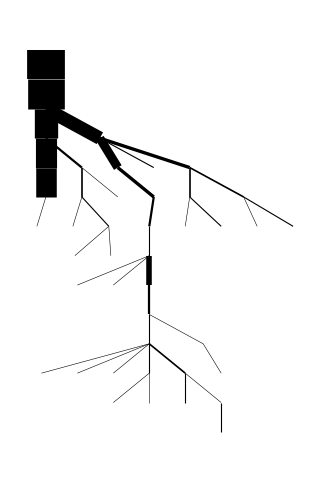

Treeb 58, acc=0.59, path=('W', 'K')


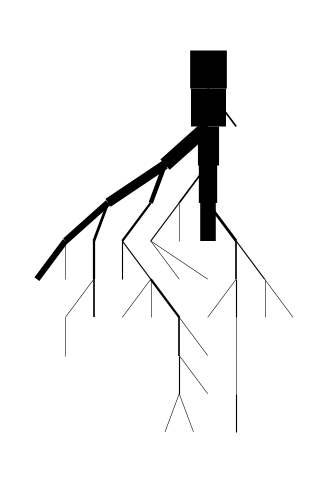

Treeb 18, acc=0.59, path=('K', 'L')


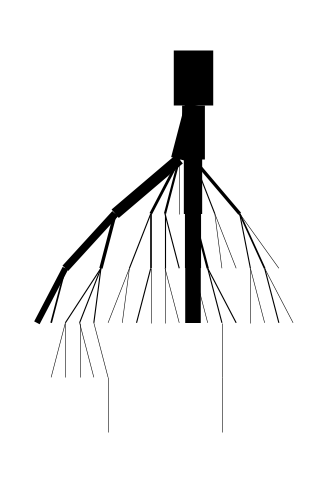

Treeb 50, acc=0.59, path=('P', 'K')


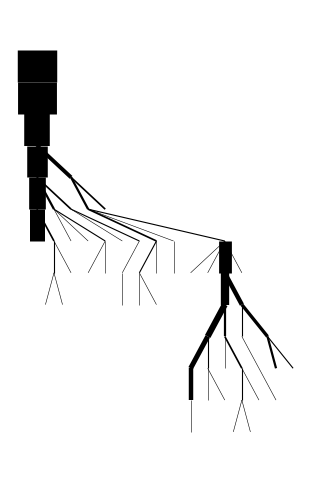

Treeb 17, acc=0.60, path=('K', 'I')


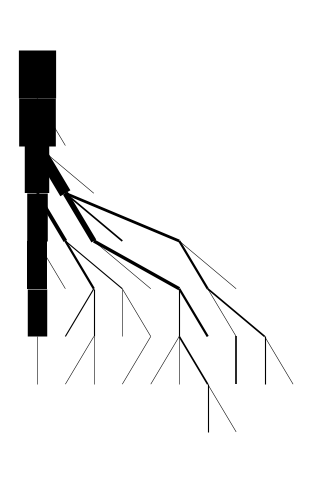

Treeb 53, acc=0.60, path=('P', 'O')


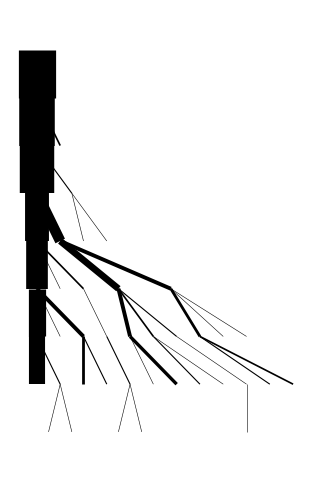

Treeb 38, acc=0.61, path=('N', 'W')


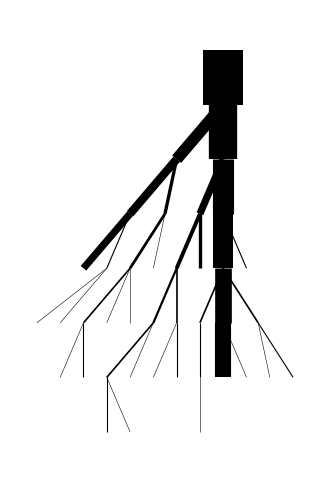

Treeb 33, acc=0.61, path=('N', 'I')


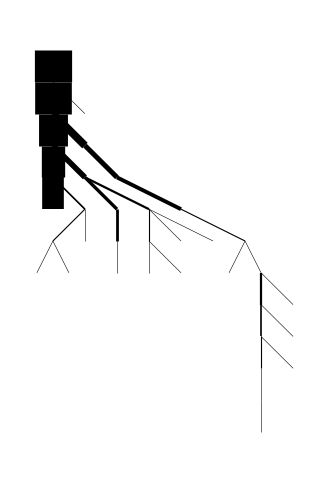

Treeb 6, acc=0.62, path=('A', 'W')


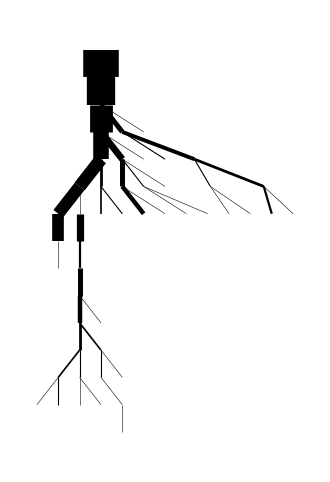

Treeb 63, acc=0.63, path=('W', 'Y')


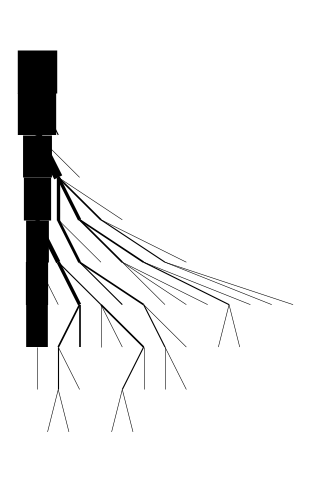

Treeb 28, acc=0.64, path=('L', 'O')


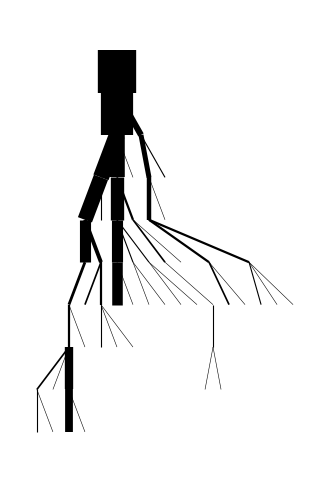

Treeb 49, acc=0.64, path=('P', 'I')


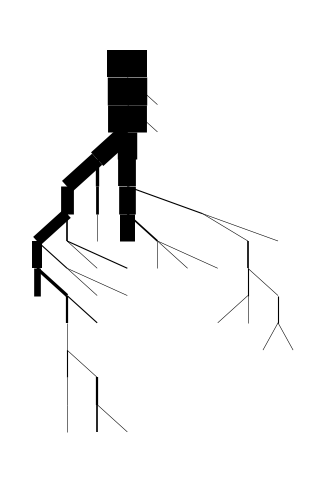

Treeb 24, acc=0.64, path=('L', 'A')


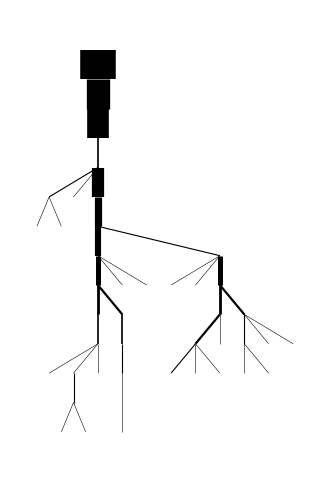

Treeb 12, acc=0.65, path=('I', 'O')


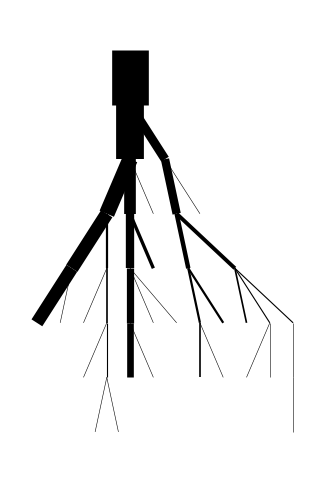

Treeb 46, acc=0.65, path=('O', 'W')


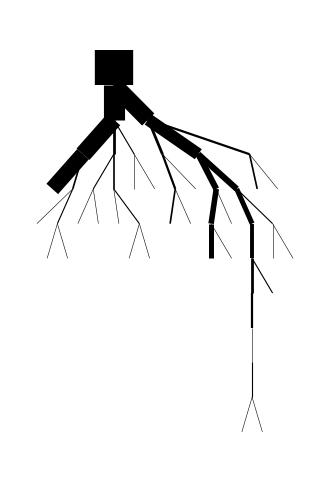

Treeb 71, acc=0.66, path=('Y', 'W')


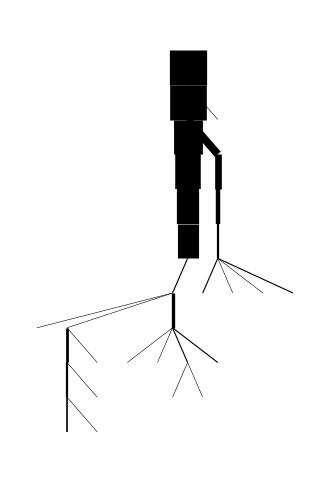

Treeb 14, acc=0.66, path=('I', 'W')


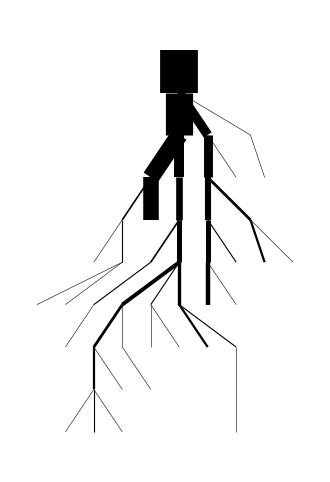

Treeb 22, acc=0.67, path=('K', 'W')


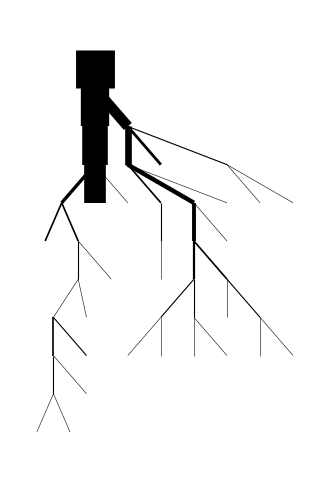

Treeb 30, acc=0.68, path=('L', 'W')


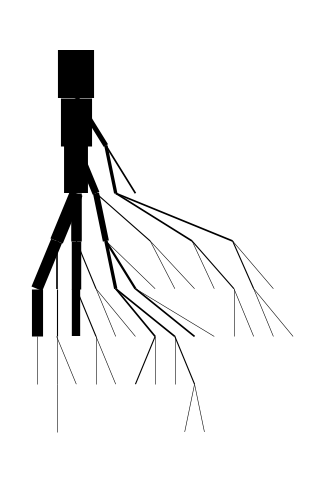

Treeb 60, acc=0.69, path=('W', 'N')


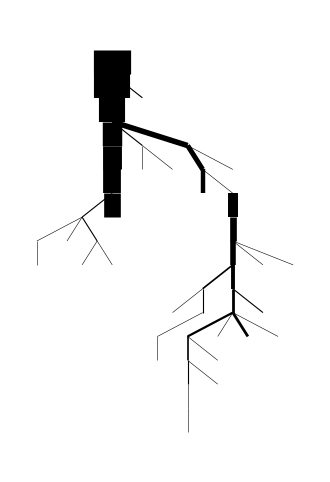

Treeb 4, acc=0.70, path=('A', 'O')


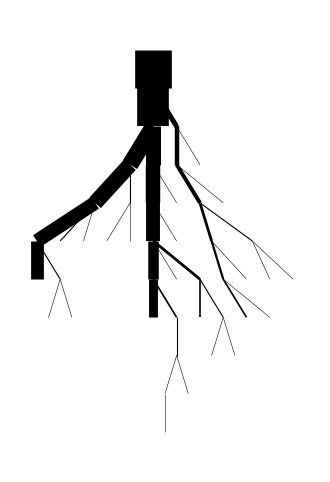

Treeb 36, acc=0.71, path=('N', 'O')


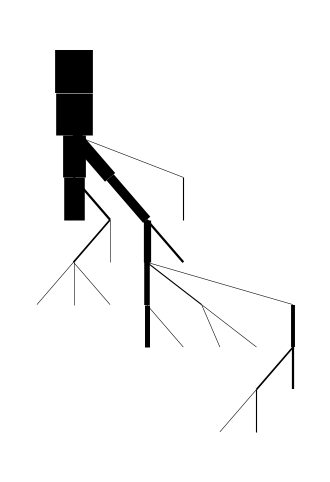

Treeb 3, acc=0.72, path=('A', 'N')


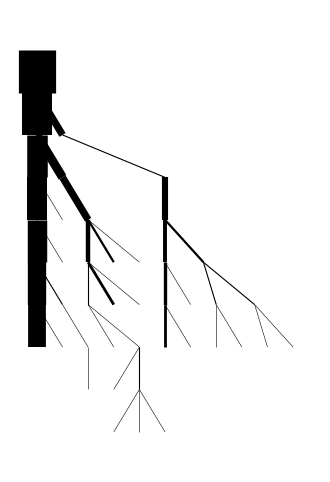

Treeb 27, acc=0.73, path=('L', 'N')


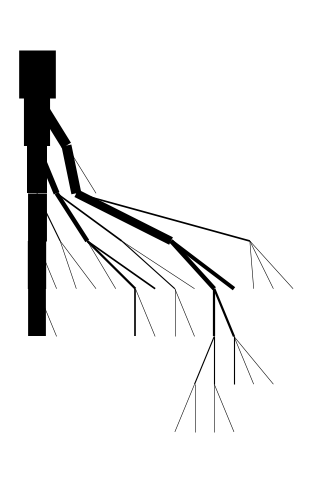

Treeb 2, acc=0.73, path=('A', 'L')


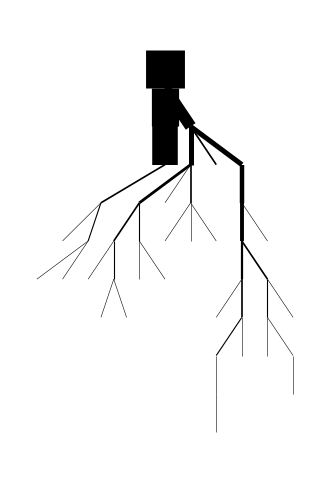

Treeb 19, acc=0.73, path=('K', 'N')


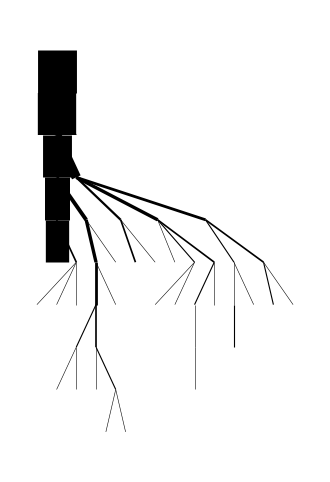

Treeb 20, acc=0.75, path=('K', 'O')


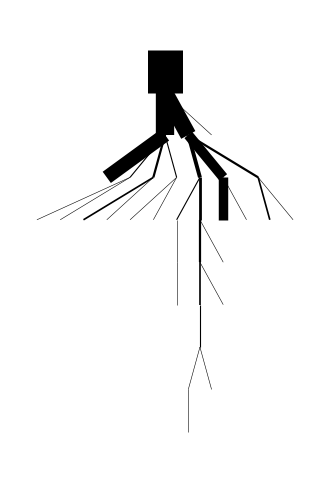

Treeb 44, acc=0.76, path=('O', 'N')


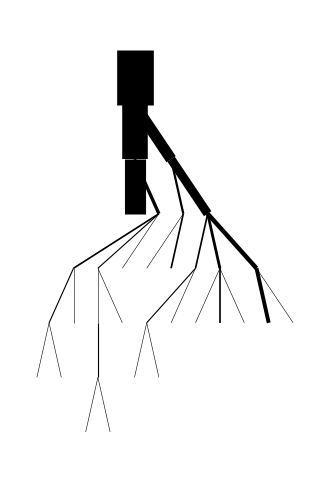

Treeb 52, acc=0.77, path=('P', 'N')


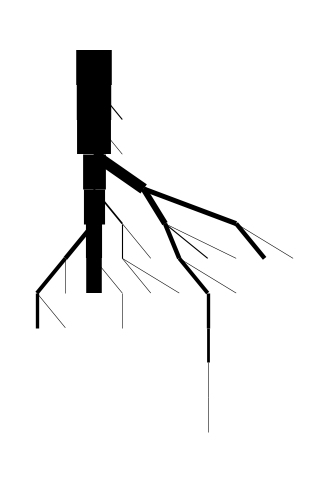

Treeb 54, acc=0.77, path=('P', 'W')


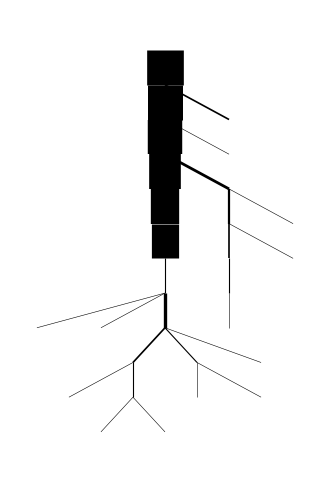

Treeb 11, acc=0.79, path=('I', 'N')


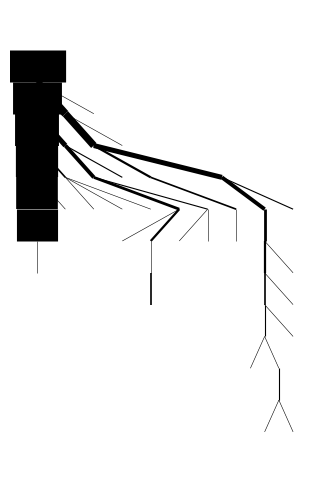

In [23]:
def plot_treeb(G):
    fig = plt.figure(figsize=(4,6))
    this_ax = plt.gca()

    pos = graphviz_layout(G, prog="dot")
    
    edges = G.edges()
    weights = [G[u][v]['weight'] * .4 for u,v in edges]

    nodes = G.nodes()
    # for n in nodes:
    #     print(n, G.nodes[n])
    n_labels = {n: n for n in G}
    n_colors = [G.nodes[n].get("color", "blue") for n in nodes]
    # print(n_colors)
    # print ((q-1) // 2, (q-1) % 2)
    # nx.draw_networkx_nodes(G, pos, node_color=n_colors, node_size=500, alpha=0.7, ax=this_ax)
    nx.draw_networkx_edges(G, pos, edgelist=edges, width=weights, ax=this_ax)
    # nx.draw_networkx_labels(G, pos, labels=n_labels, font_size=13, ax=this_ax) # font_weight="bold",

    this_ax.axis("off")
    plt.show()

sorted_order = [x for x in sorted(range(len(accs)), key=lambda x: accs[x])]
c=0
for i in sorted_order:
    print(f"Treeb {i}, acc={accs[i]:.2f}, path={paths[i]}")
    plot_treeb(flow_trees[i])
    # if c>5:
    #     break
    # c += 1